<a href="https://colab.research.google.com/github/aniqarahman/portfolio/blob/main/(Version_2)_Program_Participation_Forecasting_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font size = 6> Program Participation Forecasting Project </font> <br>

Completed by Juan Pablo and Aniqa Rahman

<font size = 5> Client Registration </font> <br>

The following section covers EDA and the time series modeling of the client registration data.


In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.dates as mdates



In [ ]:
df=pd.read_csv('ClientRegistrationClean_2021to2025Q3.csv',na_values=['#NAME?'])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
df.head()

,ID,Date,Quarter,Month,MonthNum,The Preferred method(s) of contact,City,Location,Zip code,Birthdate,...,"If referred by an agency, please provide their name",Add any additional notes or comments from the participant,Question,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61
0,58,3/8/2022,Q3,ago,8.0,Phone Call,NaN,"Covina, CA",91722.0,11/6/1987,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,34,2/3/2022,Q1,mar,3.0,Phone Call,NaN,"Pomona, CA",91767.0,23/6/1984,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13,9/11/2021,Q4,nov,11.0,NaN,NaN,"Pomona, CA",91767.0,13/8/2002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,15,10/11/2021,Q4,nov,11.0,NaN,NaN,"Las Vegas, NV",89110.0,27/4/2002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,21,8/12/2021,Q4,dic,12.0,Text Message,NaN,"Lake Elsinore, CA",92530.0,21/3/2002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 62 columns):
 #   Column                                                                                         Non-Null Count  Dtype  
---  ------                                                                                         --------------  -----  
 0   ID                                                                                             255 non-null    int64  
 1   Date                                                                                           255 non-null    object 
 2   Quarter                                                                                        189 non-null    object 
 3   Month                                                                                          221 non-null    object 
 4   MonthNum                                                                                       189 non-null    float64
 5   The Preferred method(s

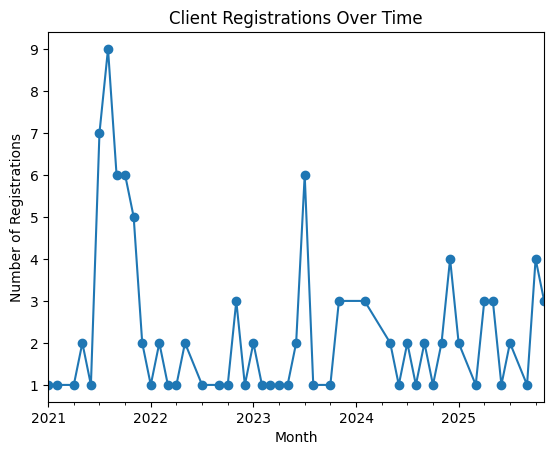

In [ ]:
#Registrations over time

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df.groupby(df["Date"].dt.to_period("M")).size().plot(kind="line", marker="o")

plt.title("Client Registrations Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Registrations")
plt.show()

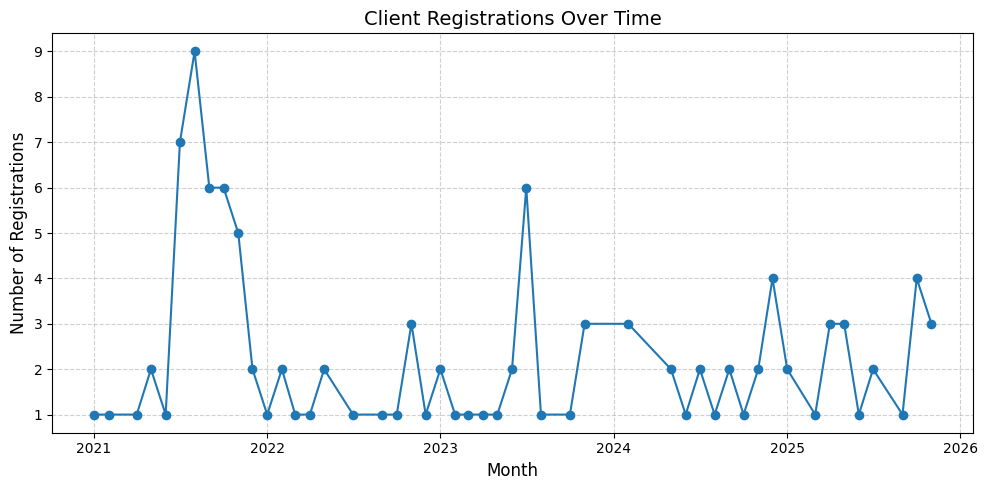

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
registrations = df.groupby(df["Date"].dt.to_period("M")).size()
registrations.index = registrations.index.to_timestamp()

# Plot
plt.figure(figsize=(10,5))
plt.plot(registrations.index, registrations.values, marker="o", linestyle="-")

plt.title("Client Registrations Over Time", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Registrations", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

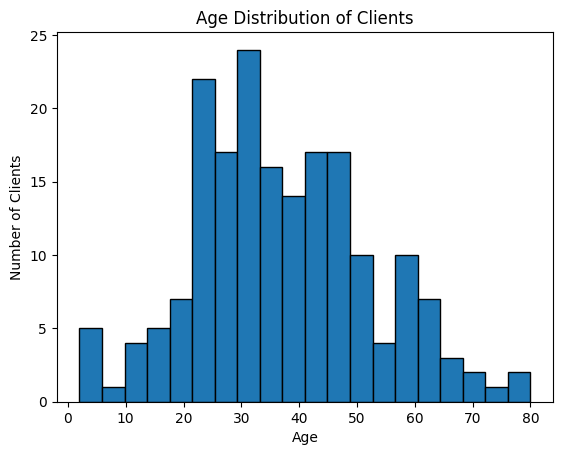

In [ ]:
#Age plots

df["Age"].dropna().astype(int).plot(kind="hist", bins=20, edgecolor="black")

plt.title("Age Distribution of Clients")
plt.xlabel("Age")
plt.ylabel("Number of Clients")
plt.show()

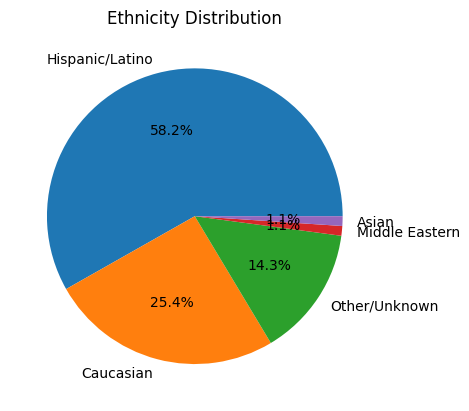

In [ ]:
df["Ethnicity"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Ethnicity Distribution")
plt.ylabel("")
plt.show()

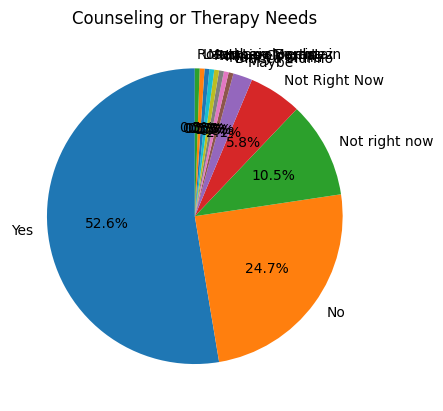

In [ ]:
#therapy needs: Program

counseling_counts = df["Counseling or Therapy Needs?"].value_counts(dropna=True)
counseling_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    ylabel=""
)

plt.title("Counseling or Therapy Needs")
plt.show()

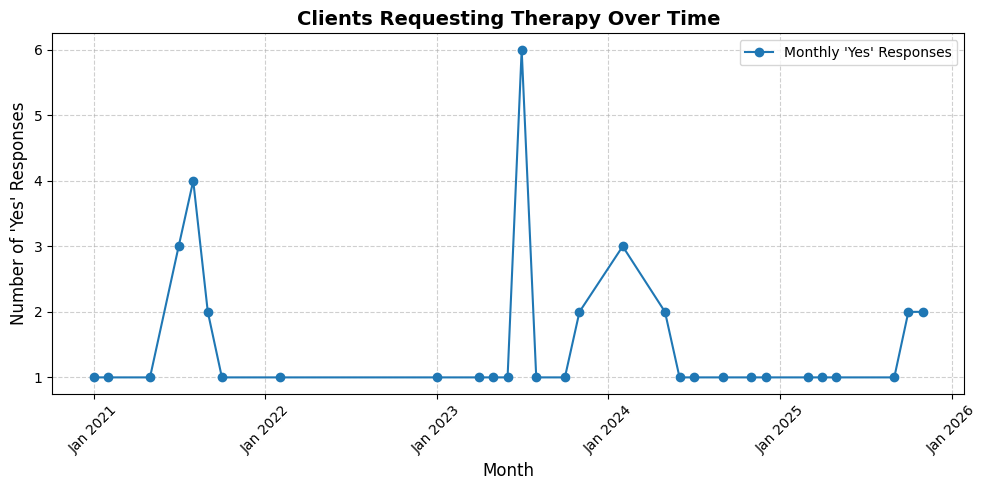

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# only "yes" responses
yes_df = df[df["Counseling or Therapy Needs?"].str.strip().str.lower() == "yes"]

yes_counts = yes_df.groupby(yes_df["Date"].dt.to_period("M")).size()
yes_counts.index = yes_counts.index.to_timestamp()

yes_ma = yes_counts.rolling(3).mean()

# --- Plot ---
plt.figure(figsize=(10,5))
plt.plot(yes_counts.index, yes_counts.values, marker="o", label="Monthly 'Yes' Responses")

plt.title("Clients Requesting Therapy Over Time", fontsize=14, weight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of 'Yes' Responses", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

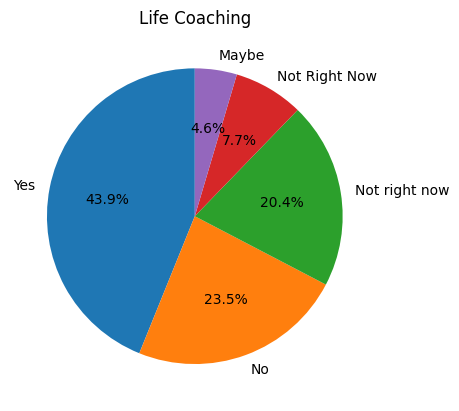

In [ ]:
#now for life coaching
life_counts = df["Life Coaching?"].value_counts(dropna=True)


life_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    ylabel=""
)

plt.title("Life Coaching")
plt.show()

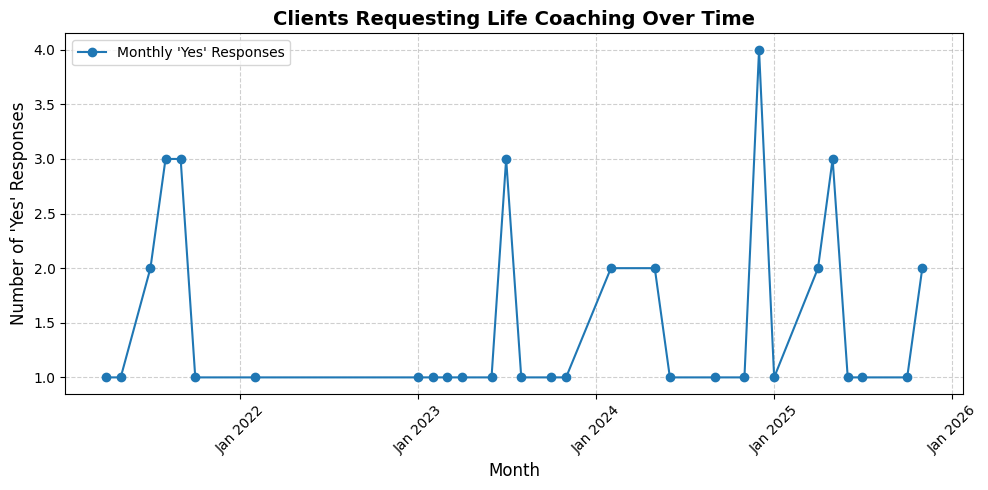

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

yes_life = df[df["Life Coaching?"].str.strip().str.lower() == "yes"]
yes_life_counts = yes_life.groupby(yes_life["Date"].dt.to_period("M")).size()
yes_life_counts.index = yes_life_counts.index.to_timestamp()

yes_life_ma = yes_life_counts.rolling(3).mean()

# --- Plot ---
plt.figure(figsize=(10,5))
plt.plot(yes_life_counts.index, yes_life_counts.values, marker="o", label="Monthly 'Yes' Responses")
plt.title("Clients Requesting Life Coaching Over Time", fontsize=14, weight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of 'Yes' Responses", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/di

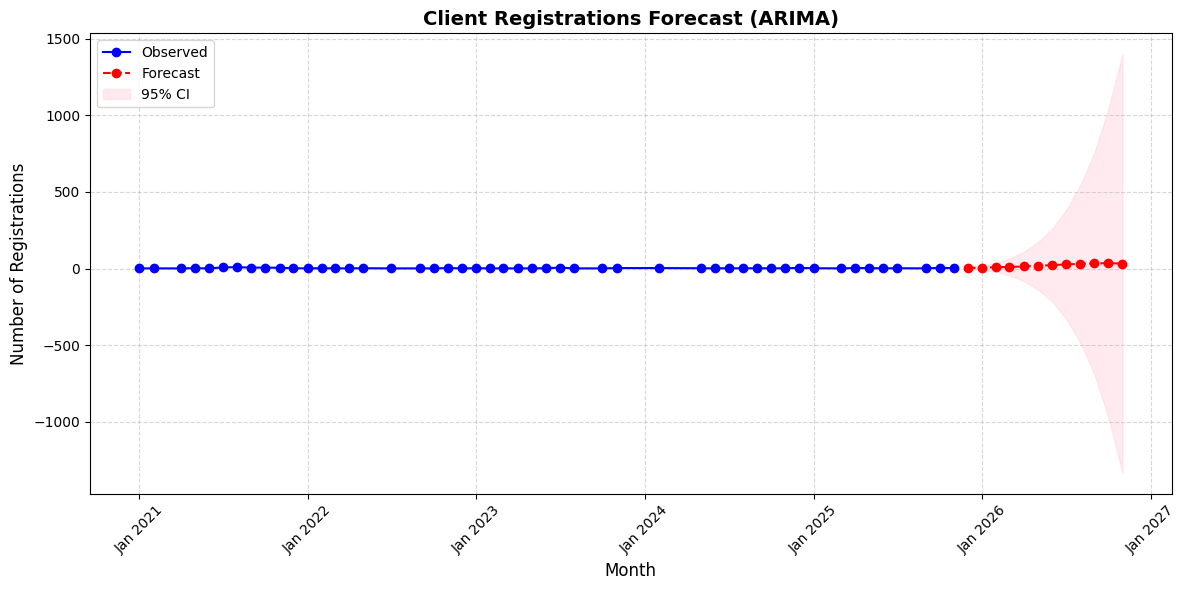

In [ ]:
ts = df.groupby(df["Date"].dt.to_period("M")).size()
ts.index = ts.index.to_timestamp()

# ARIMA model
model = ARIMA(ts, order=(6,8,4))
model_fit = model.fit()
forecast = model_fit.get_forecast(steps=12)
forecast_index = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq='MS')

# Plot
plt.figure(figsize=(12,6))

plt.plot(ts, marker="o", label="Observed", color="blue")

plt.plot(forecast_index, forecast.predicted_mean, marker="o", linestyle="--", color="red", label="Forecast")

ci = forecast.conf_int()
plt.fill_between(forecast_index, ci.iloc[:,0], ci.iloc[:,1], color="pink", alpha=0.3, label="95% CI")

plt.title("Client Registrations Forecast (ARIMA)", fontsize=14, weight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Registrations", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#For therapy and mentorship
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

therapy_ts = df[df["Counseling or Therapy Needs?"].str.strip().str.lower() == "yes"]
therapy_ts = therapy_ts.groupby(therapy_ts["Date"].dt.to_period("M")).size()
therapy_ts.index = therapy_ts.index.to_timestamp()

life_ts = df[df["Life Coaching?"].str.strip().str.lower() == "yes"]
life_ts = life_ts.groupby(life_ts["Date"].dt.to_period("M")).size()
life_ts.index = life_ts.index.to_timestamp()

# therapy model
therapy_model = ARIMA(therapy_ts, order=(2,1,1))
therapy_fit = therapy_model.fit()

# life coaching model
life_model = ARIMA(life_ts, order=(2,1,1))
life_fit = life_model.fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


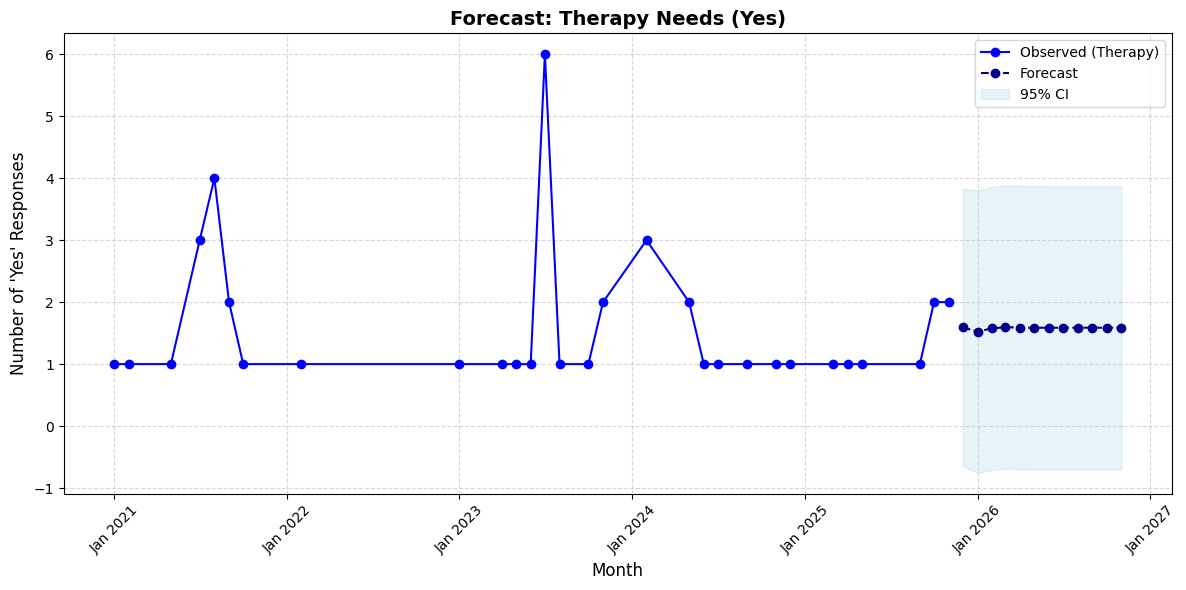

In [ ]:
therapy_forecast = therapy_fit.get_forecast(steps=12)
therapy_index = pd.date_range(therapy_ts.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq='MS')

# --- Plot ---
plt.figure(figsize=(12,6))
plt.plot(therapy_ts, marker="o", label="Observed (Therapy)", color="blue")
plt.plot(therapy_index, therapy_forecast.predicted_mean, marker="o", linestyle="--", color="darkblue", label="Forecast")
ci = therapy_forecast.conf_int()
plt.fill_between(therapy_index, ci.iloc[:,0], ci.iloc[:,1], color="lightblue", alpha=0.3, label="95% CI")
plt.title("Forecast: Therapy Needs (Yes)", fontsize=14, weight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of 'Yes' Responses", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


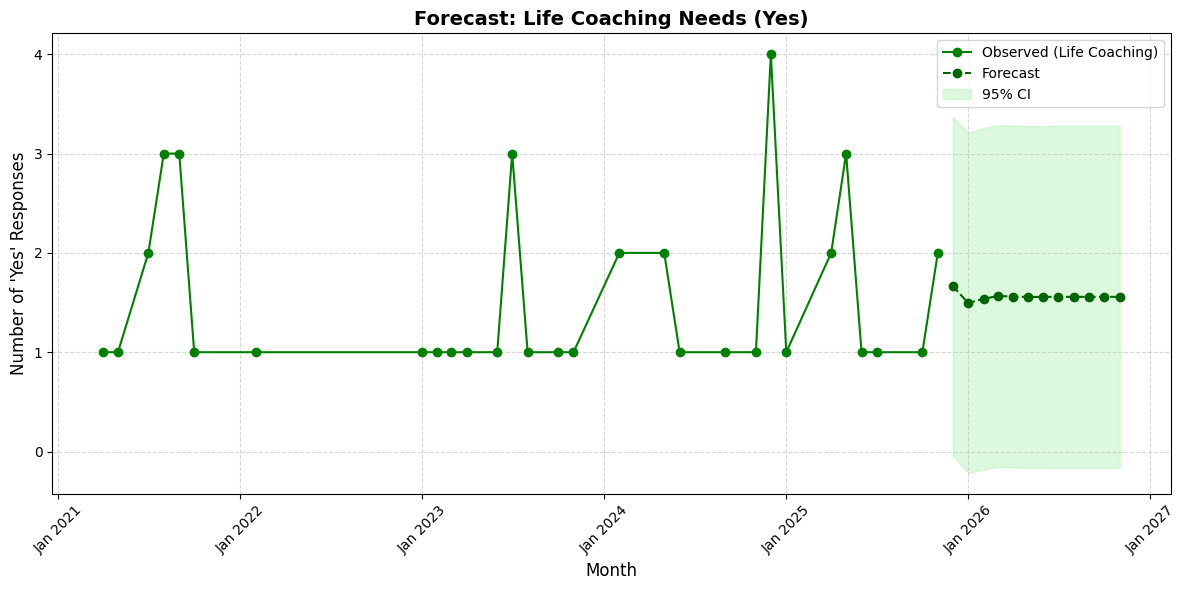

In [ ]:
life_forecast = life_fit.get_forecast(steps=12)
life_index = pd.date_range(life_ts.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq='MS')

# --- Plot ---
plt.figure(figsize=(12,6))
plt.plot(life_ts, marker="o", label="Observed (Life Coaching)", color="green")
plt.plot(life_index, life_forecast.predicted_mean, marker="o", linestyle="--", color="darkgreen", label="Forecast")
ci = life_forecast.conf_int()
plt.fill_between(life_index, ci.iloc[:,0], ci.iloc[:,1], color="lightgreen", alpha=0.3, label="95% CI")
plt.title("Forecast: Life Coaching Needs (Yes)", fontsize=14, weight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of 'Yes' Responses", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<font size = 5> Life Coaching </font> <br>

The following section covers EDA and the time series modeling of the life coaching data.

In [ ]:
#lc referring to Life Coaching
lc = pd.read_csv('Life Coaching_2024.csv',  encoding="latin1")
lc.head(5)

,ID,Start time,Completion time,Email,Name,Last modified time,9/25/2024,First Name,Last Name,May we call,...,Last Name2,Relationship,Phone Number,Client is a Minor,Please check any of the following areas you'd like to integrate more into your daily life:,"Coaching is an ongoing relationship between a coach and a person who desires coaching. We agree that: \n\n1. Coaching is not a therapy, counseling, advice giving or mental health care. The coach...",Question,"Coaching is an ongoing relationship between a coach and a person who desires coaching. We agree that: \n\n1. Coaching is not a therapy, counseling, advice giving or mental health care. The coach...2","Other specifics about your coaching sessions: \n\n1. Your coaching session will be 45-50 minutes duration \n2. To reach your coach, call Thaddeus Resource Center at 909-599-2111 during office...",Question2
0,1,3/19/24 17:16:56,3/19/24 17:21:55,anonymous,NaN,NaN,3/19/2024,Nicole,Brandt,NaN,...,NaN,NaN,NaN,No,Relationships,Nicole Brandt,NaN,NaN,Nicole Brandt,NaN
1,2,3/26/24 15:12:24,3/26/24 15:16:04,anonymous,NaN,NaN,3/26/2024,Caroline,Omidiji,NaN,...,Omidiji,Mother,6462483085,No,Relationships,Caroline Omidiji,NaN,NaN,Caroline Omidiji,NaN
2,3,3/26/24 20:52:58,3/26/24 21:22:24,anonymous,NaN,NaN,3/26/2024,brianna,sewell,NaN,...,sewell,Mother,6264431831,No,Spirituality,Brianna Sewell,NaN,NaN,Brianna Sewell,NaN
3,4,4/10/24 12:08:37,4/10/24 12:44:45,anonymous,NaN,NaN,4/10/2024,Michelle,Mar,NaN,...,Mar,Friend,7145643214,No,Finances,Michelle mar,NaN,NaN,Michelle m,NaN
4,5,4/12/24 17:39:47,4/12/24 17:52:53,anonymous,NaN,NaN,1/19/1995,Karesha,Martin,NaN,...,Magee,Mother,6262193001,No,Creativity,Karesha Martin,NaN,NaN,Karesha Martin,NaN


In [ ]:
lc['Month'] = lc['Completion time'].str.extract('^(\d{1,2})')
lc["Date"] = lc["Completion time"].str.extract('^([^ ]*)')
lc.head(5)
#creating data column to group based on that later for barplots


,ID,Start time,Completion time,Email,Name,Last modified time,9/25/2024,First Name,Last Name,May we call,...,Phone Number,Client is a Minor,Please check any of the following areas you'd like to integrate more into your daily life:,"Coaching is an ongoing relationship between a coach and a person who desires coaching. We agree that: \n\n1. Coaching is not a therapy, counseling, advice giving or mental health care. The coach...",Question,"Coaching is an ongoing relationship between a coach and a person who desires coaching. We agree that: \n\n1. Coaching is not a therapy, counseling, advice giving or mental health care. The coach...2","Other specifics about your coaching sessions: \n\n1. Your coaching session will be 45-50 minutes duration \n2. To reach your coach, call Thaddeus Resource Center at 909-599-2111 during office...",Question2,Month,Date
0,1,3/19/24 17:16:56,3/19/24 17:21:55,anonymous,NaN,NaN,3/19/2024,Nicole,Brandt,NaN,...,NaN,No,Relationships,Nicole Brandt,NaN,NaN,Nicole Brandt,NaN,3,3/19/24
1,2,3/26/24 15:12:24,3/26/24 15:16:04,anonymous,NaN,NaN,3/26/2024,Caroline,Omidiji,NaN,...,6462483085,No,Relationships,Caroline Omidiji,NaN,NaN,Caroline Omidiji,NaN,3,3/26/24
2,3,3/26/24 20:52:58,3/26/24 21:22:24,anonymous,NaN,NaN,3/26/2024,brianna,sewell,NaN,...,6264431831,No,Spirituality,Brianna Sewell,NaN,NaN,Brianna Sewell,NaN,3,3/26/24
3,4,4/10/24 12:08:37,4/10/24 12:44:45,anonymous,NaN,NaN,4/10/2024,Michelle,Mar,NaN,...,7145643214,No,Finances,Michelle mar,NaN,NaN,Michelle m,NaN,4,4/10/24
4,5,4/12/24 17:39:47,4/12/24 17:52:53,anonymous,NaN,NaN,1/19/1995,Karesha,Martin,NaN,...,6262193001,No,Creativity,Karesha Martin,NaN,NaN,Karesha Martin,NaN,4,4/12/24


In [ ]:
lc.columns

Index(['ID', 'Start time', 'Completion time', 'Email', 'Name',
       'Last modified time', '9/25/2024', 'First Name', 'Last Name',
       'May we call',
       'Preferred Method of Contact (please select all that apply)',
       'Email Address', 'Cell Phone Number',
       'May we leave a voicemail at the phone number provided?',
       'May we leave a voicemail at the phone number provided?2',
       'May we email you at this email address?',
       'May we text you at the phone number provided?',
       'What is the best day and time to have our life coach contact you?',
       'Preferred Name', 'Address', 'City', 'State', 'ZIP code',
       'Date of Birth (only to confirm age)',
       'Date of Birth (only to confirm age) ', 'Any comments', 'Gender',
       'Intake Questionnaire',
       'What brings you to coaching at this time? Is there something specific, such as a particular event or life experience? Be as detailed as you can. ',
       'What would you like to accomplish in our

<font size = 3> Forming Age Distribution </font>

In [ ]:
lc.drop(columns = lc.columns[23], axis = 1) #dropping the duplicate column of DOB. the first occurrence only had NaN values
#here, I'll be getting the age by taking the difference between the completion date and DOB
lc["Date"] = pd.to_datetime(lc["Date"])
lc["Date of Birth"] = pd.to_datetime(lc.iloc[:, 24])
lc['Age (time of completion)'] = (lc["Date"] - lc["Date of Birth"]).dt.days / 365.25
lc['Age (time of completion)'] = lc['Age (time of completion)'].astype(int)
lc.head(5) #printing to make sure each change made is correct

,ID,Start time,Completion time,Email,Name,Last modified time,9/25/2024,First Name,Last Name,May we call,...,Please check any of the following areas you'd like to integrate more into your daily life:,"Coaching is an ongoing relationship between a coach and a person who desires coaching. We agree that: \n\n1. Coaching is not a therapy, counseling, advice giving or mental health care. The coach...",Question,"Coaching is an ongoing relationship between a coach and a person who desires coaching. We agree that: \n\n1. Coaching is not a therapy, counseling, advice giving or mental health care. The coach...2","Other specifics about your coaching sessions: \n\n1. Your coaching session will be 45-50 minutes duration \n2. To reach your coach, call Thaddeus Resource Center at 909-599-2111 during office...",Question2,Month,Date,Date of Birth,Age (time of completion)
0,1,3/19/24 17:16:56,3/19/24 17:21:55,anonymous,NaN,NaN,3/19/2024,Nicole,Brandt,NaN,...,Relationships,Nicole Brandt,NaN,NaN,Nicole Brandt,NaN,3,2024-03-19,1991-07-07,32
1,2,3/26/24 15:12:24,3/26/24 15:16:04,anonymous,NaN,NaN,3/26/2024,Caroline,Omidiji,NaN,...,Relationships,Caroline Omidiji,NaN,NaN,Caroline Omidiji,NaN,3,2024-03-26,1995-08-12,28
2,3,3/26/24 20:52:58,3/26/24 21:22:24,anonymous,NaN,NaN,3/26/2024,brianna,sewell,NaN,...,Spirituality,Brianna Sewell,NaN,NaN,Brianna Sewell,NaN,3,2024-03-26,1996-02-03,28
3,4,4/10/24 12:08:37,4/10/24 12:44:45,anonymous,NaN,NaN,4/10/2024,Michelle,Mar,NaN,...,Finances,Michelle mar,NaN,NaN,Michelle m,NaN,4,2024-04-10,1995-02-02,29
4,5,4/12/24 17:39:47,4/12/24 17:52:53,anonymous,NaN,NaN,1/19/1995,Karesha,Martin,NaN,...,Creativity,Karesha Martin,NaN,NaN,Karesha Martin,NaN,4,2024-04-12,1995-01-19,29


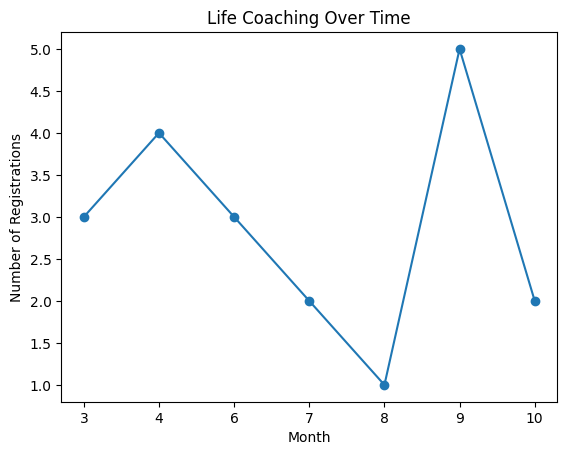

In [ ]:
lc.groupby('Month', sort = False).size().plot(kind="line", marker="o")

plt.title("Life Coaching Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Registrations")
plt.show()

#each number on x-axis denotes a month e.g 9 = Septemeber


<Axes: xlabel='Client is a Minor'>

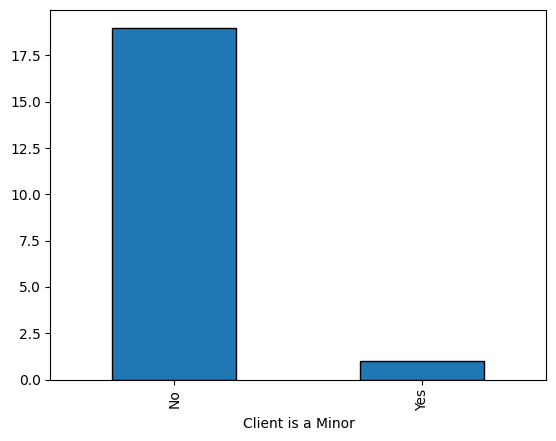

In [ ]:
lc.groupby('Client is a Minor', sort = False).size().plot(kind="bar", edgecolor="black")
#most people seeking Life Coaching are not minors

It might be worth noting most seeking life coaching at Thaddeus are not minors. This data might not be fully representative but it would be logical to assume most people that are seeking life coaching are older since they might need to support themselves financially or independently from their family. With a bigger dataset, it would be worth taking a quick look at this stat so we can allocate other resources like adolescent counseling that might be more relevant to minors and making sure life coachers are adults with adequate life experience that can offer valuable life advice rather than younger groups like college-aged interns.

35.9


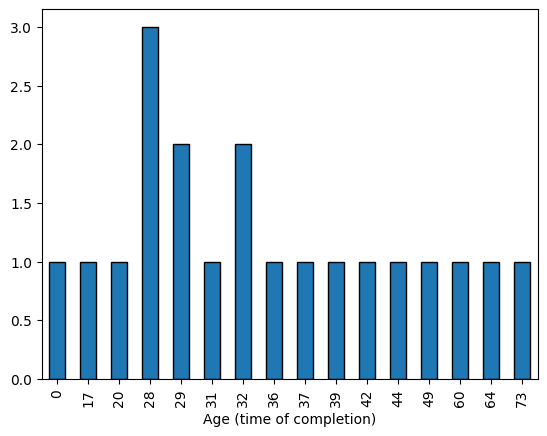

In [ ]:
lc.groupby('Age (time of completion)').size().plot(kind="bar", edgecolor="black")
print(lc['Age (time of completion)'].mean())

In the next few cells, I'll be exploring the column 'Please check any of the following areas you'd like to integrate more into your daily life'. This column stores a concatenated string for each client and each string contain various area each client wants guidance in the following format (relationships;education;spirituality;joy). I will use Regex to separate the strings and then manipulate it so I can see a barplot that shows the count for each aspect. I'll be storing the separated data in a **dataframe** for calculations later on. Exploring this will help determine what it is clients are looking for in the programs. Note that the goals dataframe is being created just for the barplot and will not be used anywhere beyond this section.

In [ ]:
goals = lc["Please check any of the following areas you'd like to integrate more into your daily life:"].str.split(";", expand = True)
goals.head(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Relationships,None,None,None,None,None,None,None,None,None,None,None,None
1,Relationships,None,None,None,None,None,None,None,None,None,None,None,None
2,Spirituality,None,None,None,None,None,None,None,None,None,None,None,None
3,Finances,None,None,None,None,None,None,None,None,None,None,None,None
4,Creativity,None,None,None,None,None,None,None,None,None,None,None,None


In [ ]:
combined_all = goals.stack().value_counts()
combined_all = combined_all[1:]
combined_all

,count
Relationships,10
Spirituality,9
Social Life,9
Health,9
Joy,8
Home Environment,8
Creativity,8
Physical Activity,8
Finances,7
Career,7


Text(0, 0.5, 'Count')

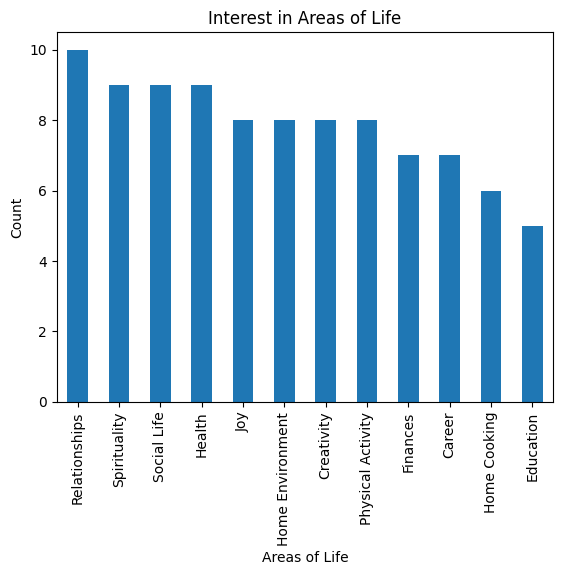

In [ ]:
combined_all.plot(kind='bar')
plt.title('Interest in Areas of Life')
plt.xlabel('Areas of Life')
plt.ylabel('Count') #how many times each area was mentioned in the whole dataset

From this barplot, it's evident relationships, followed by spirtuality, social life, and health, have been mentioned the most by clients interested in life coaching. Education and home cooking were mentioned the least.

In [ ]:
lc["goals_regex"] = lc["Please check any of the following areas you'd like to integrate more into your daily life:"].str.split(";")
lc["goals_regex"]

,goals_regex
0,[Relationships]
1,[Relationships]
2,[Spirituality]
3,[Finances]
4,[Creativity]
5,[Home Environment]
6,[Finances]
7,[Physical Activity]
8,[Social Life]
9,"[Spirituality, Joy, Social Life, Relationships..."


In [ ]:
#adding necessary columns to conduct each time series model. go all the way to the right to view following new columns
lc["has_Relationships"] = lc["goals_regex"].apply(lambda x: "Relationships" in x)
lc["has_Spirituality"] = lc["goals_regex"].apply(lambda x: "Spirituality" in x)
lc["has_SocialLife"] = lc["goals_regex"].apply(lambda x: "SocialLife" in x)
lc["has_Health"] = lc["goals_regex"].apply(lambda x: "Health" in x)
lc["has_Education"] = lc["goals_regex"].apply(lambda x: "Education" in x)

lc.head(5)


,ID,Start time,Completion time,Email,Name,Last modified time,9/25/2024,First Name,Last Name,May we call,...,Month,Date,Date of Birth,Age (time of completion),goals_regex,has_Relationships,has_Spirituality,has_SocialLife,has_Health,has_Education
0,1,3/19/24 17:16:56,3/19/24 17:21:55,anonymous,NaN,NaN,3/19/2024,Nicole,Brandt,NaN,...,3,2024-03-19,1991-07-07,32,[Relationships],True,False,False,False,False
1,2,3/26/24 15:12:24,3/26/24 15:16:04,anonymous,NaN,NaN,3/26/2024,Caroline,Omidiji,NaN,...,3,2024-03-26,1995-08-12,28,[Relationships],True,False,False,False,False
2,3,3/26/24 20:52:58,3/26/24 21:22:24,anonymous,NaN,NaN,3/26/2024,brianna,sewell,NaN,...,3,2024-03-26,1996-02-03,28,[Spirituality],False,True,False,False,False
3,4,4/10/24 12:08:37,4/10/24 12:44:45,anonymous,NaN,NaN,4/10/2024,Michelle,Mar,NaN,...,4,2024-04-10,1995-02-02,29,[Finances],False,False,False,False,False
4,5,4/12/24 17:39:47,4/12/24 17:52:53,anonymous,NaN,NaN,1/19/1995,Karesha,Martin,NaN,...,4,2024-04-12,1995-01-19,29,[Creativity],False,False,False,False,False


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


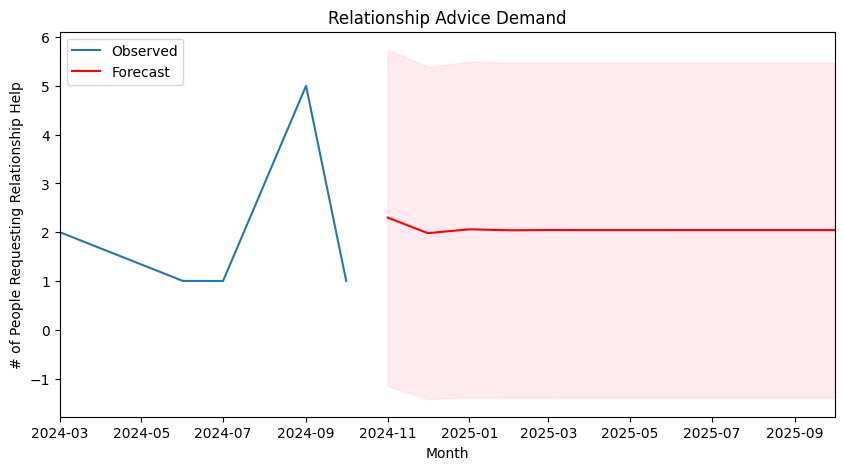

In [ ]:
relationship_df = lc[lc["has_Relationships"] == True]
relationship_df = relationship_df.groupby(relationship_df["Date"].dt.to_period("M")).size()
relationship_df.index = relationship_df.index.to_timestamp()
relationship_model = ARIMA(relationship_df, order = (1,1,1))
relationship_fit = relationship_model.fit()


rel_forecast = relationship_fit.get_forecast(steps=12)
rel_forecast_index = pd.date_range(relationship_df.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq='MS')


plt.figure(figsize=(10,5))
plt.plot(relationship_df.index, relationship_df.values, label="Observed")
plt.plot(rel_forecast_index, rel_forecast.predicted_mean, label="Forecast", color='red')
plt.fill_between(rel_forecast_index,
                 rel_forecast.conf_int()["lower y"],
                 rel_forecast.conf_int()["upper y"],
                 color='pink', alpha=0.3)

plt.title("Relationship Advice Demand")
plt.xlabel("Month")
plt.ylabel("# of People Requesting Relationship Help")
plt.legend()

plt.xlim([relationship_df.index.min(), rel_forecast_index[-1]])

plt.show()


There is a steady demand for relationship advice we can anticipate for the rest of the year. Looking at the data, relationship advice might be the most demanded advice topic in life coaching compared to other topics.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


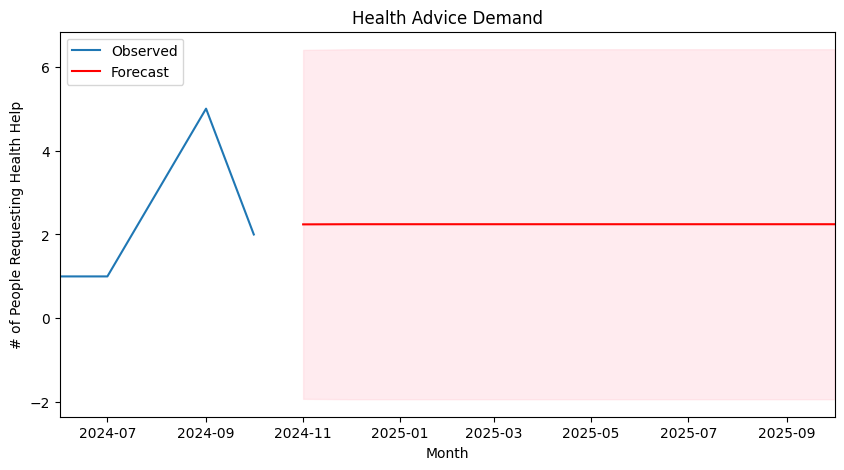

In [ ]:
health_df = lc[lc["has_Health"] == True]
health_df = health_df.groupby(health_df["Date"].dt.to_period("M")).size()
health_df.index = health_df.index.to_timestamp()
health_model = ARIMA(health_df, order = (1,1,1))
health_fit = health_model.fit()


health_forecast = health_fit.get_forecast(steps=12)
health_forecast_index = pd.date_range(health_df.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq='MS')



plt.figure(figsize=(10,5))
plt.plot(health_df.index, health_df.values, label="Observed")
plt.plot(health_forecast_index, health_forecast.predicted_mean, label="Forecast", color='red')
plt.fill_between(health_forecast_index,
                 health_forecast.conf_int()["lower y"],
                 health_forecast.conf_int()["upper y"],
                 color='pink', alpha=0.3)
plt.title("Health Advice Demand")
plt.xlabel("Month")
plt.ylabel("# of People Requesting Health Help")
plt.legend()
plt.xlim([health_df.index.min(), health_forecast_index[-1]])
plt.show()

There is a steady demand for health advice we can anticipate for the rest of the year. Around 2 people per month will ask for help on health.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


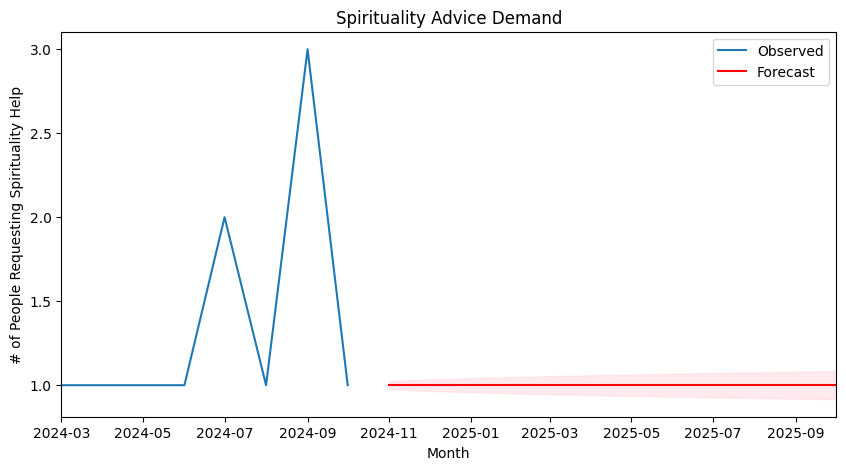

In [ ]:
spi_df = lc[lc["has_Spirituality"] == True]
spi_df = spi_df.groupby(spi_df["Date"].dt.to_period("M")).size()
spi_df.index = spi_df.index.to_timestamp()
spi_model = ARIMA(spi_df, order = (1,1,1))
spi_fit = spi_model.fit()


spi_forecast = spi_fit.get_forecast(steps=12)
spi_forecast_index = pd.date_range(spi_df.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq='MS')



plt.figure(figsize=(10,5))
plt.plot(spi_df.index, spi_df.values, label="Observed")
plt.plot(spi_forecast_index, spi_forecast.predicted_mean, label="Forecast", color='red')
plt.fill_between(spi_forecast_index,
                 spi_forecast.conf_int()["lower y"],
                 spi_forecast.conf_int()["upper y"],
                 color='pink', alpha=0.3)
plt.title("Spirituality Advice Demand")
plt.xlabel("Month")
plt.ylabel("# of People Requesting Spirituality Help")
plt.legend()
plt.xlim([spi_df.index.min(), spi_forecast_index[-1]])
plt.show()

There was a slight spike on spirtuality advice but there's a slightly lower demand for advice on spirtuality compared to relationship and health advice.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/di

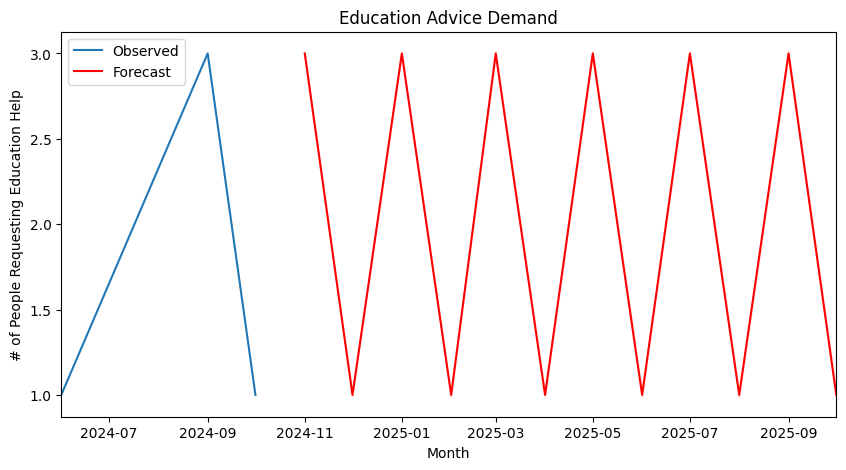

In [ ]:
edu_df = lc[lc["has_Education"] == True]
edu_df = edu_df.groupby(edu_df["Date"].dt.to_period("M")).size()
edu_df.index = edu_df.index.to_timestamp()
edu_model = ARIMA(edu_df, order = (1,1,1))
edu_fit = edu_model.fit()


edu_forecast = edu_fit.get_forecast(steps=12)
edu_forecast_index = pd.date_range(edu_df.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq='MS')



plt.figure(figsize=(10,5))
plt.plot(edu_df.index, edu_df.values, label="Observed")
plt.plot(edu_forecast_index, edu_forecast.predicted_mean, label="Forecast", color='red')
plt.fill_between(edu_forecast_index,
                 edu_forecast.conf_int()["lower y"],
                 edu_forecast.conf_int()["upper y"],
                 color='pink', alpha=0.3)
plt.title("Education Advice Demand")
plt.xlabel("Month")
plt.ylabel("# of People Requesting Education Help")
plt.legend()
plt.xlim([edu_df.index.min(), edu_forecast_index[-1]])
plt.show()

I don't believe this time series model is helpful to reaching any conclusions about how the trend of demand for education advice will continue. I believe this is because we have such limited data in the life coaching data frame. Although, it is worth noting the demand for education went up near September, which is around the time school starts. So the demand on education advice might be seasonal in nature. If there was more data spanning over at least a year, it would be safe to hypothesize that the demand for education advice would fluctuate at certain times like finals season around May or December.(but not systemically every other month like this graph suggests).


However, the demand for advice on relationships and health will remain at an average of 2 people per month (this could inflate if their are more registrations for life coaching). The demand for spirituality advice, despite having the same count as relationship and health, came out to an average of 1 person per month demanding they want spirituality advice. This high variance can once again be attributed to the extremely limited scope of the data set.

Although this project is mainly meant to forecast program participation, I believe analyzing the demands of the clients can be helpful in recognizing what their needs are and allocating the right amount of resources for it. For example, if we recognize have a greater need for advice on spirituality, we can provide life coachers at Thaddeus on how to adequately give advice on spirituality or allocating the people with necessary experience to address these needs.

<font size = 5>Restoration House Data </font>

This data was pulled from the restoration housing applications. Using this data, I will be building a time series model to predict an approximate number of people we can anticipate to apply for our restoration housing data.

In [ ]:
df1 = pd.read_excel('Restoration House Application(1-37).xlsx')
df1.to_csv("Restoration_House_Application.csv", index=False, encoding="utf-8")
rh = pd.read_csv("Restoration_House_Application.csv")
rh.head()

,ID,Start time,Completion time,Email,Name,Client Name:,Date of Birth:,Questions?,Gender:,Phone Number:,...,"\nAre you currently facing any related charges with probation, parole, law enforcement? \n\n","If Yes, please explain:",Any medical history or current health issues?,Any history with substance abuse?,"If yes, are you or have you been in rehab rehabilitation?",Are you currently in a Domestic relationship or a survivor of Domestic violence?,Any additional health information or special accommodations for staff to be aware of?,Have you previously applied for a registration at Thaddeus?,Any additional information that our Case managers should know?,Were you referred by another Agency/Organization or Thaddeus Employee?
0,1,2023-08-31 12:19:13,2023-08-31 12:26:29,anonymous,NaN,NaN,5/19/1970,NaN,NaN,909-789-2399,...,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2023-09-19 13:10:08,2023-09-19 13:11:46,anonymous,NaN,NaN,07/07/1991,NaN,Female,6264222926,...,No,NaN,Yes,No,No,Yes,Lupus,No,NaN,Maria
2,3,2023-09-26 20:37:20,2023-09-26 20:39:31,anonymous,NaN,NaN,11/22/1973,NaN,Female,626-827-2149,...,No,NaN,No,NaN,No,Yes,NaN,No,NaN,Yes
3,4,2023-10-11 12:02:23,2023-10-11 12:16:32,anonymous,NaN,NaN,Morales,NaN,Female,(626) 723-5477‬,...,no,NaN,Asthma,NaN,NaN,Yes,NaN,No,She is undocumented and so is her son. She has...,Maria Gonzalez- Her Case Manager
4,5,2024-01-09 17:29:21,2024-01-09 17:31:53,anonymous,NaN,NaN,10/15/1984,NaN,Female,909-675-8129,...,NaN,NaN,Diabetes,NaN,NaN,Yes,NaN,Yes,NaN,No


In [ ]:
df1.columns

Index(['ID', 'Start time', 'Completion time', 'Email', 'Name', 'Client Name:',
       'Date of Birth:', 'Questions?', 'Gender:', 'Phone Number:', 'Email:',
       'Preferred Language:',
       'Are you safe at your current temporary living residential location?',
       'Full Name of Child:', 'Date of Birth of Child?',
       'Full Name of Second Child?', 'Date of Birth of Second Child?',
       'Full Name of Third Child?', 'Date of Birth of Third Child?',
       'Are you currently employed? ',
       'If Yes, please list Occupation title in description:',
       '\nAre you currently enrolled in school: Community College, Trade School, University?\n\n',
       '\nAre you currently facing any related charges with probation, parole, law enforcement? \n\n',
       'If Yes, please explain:',
       'Any medical history or current health issues?',
       'Any history with substance abuse?',
       'If yes, are you or have you been in rehab rehabilitation?',
       'Are you currently in a Do

Text(0.5, 1.0, 'Domestic Violence Count (Restoration House)')

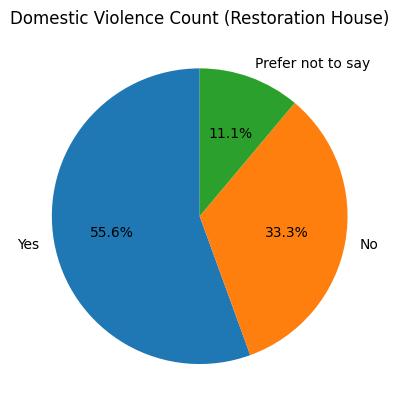

In [ ]:
domestic_violence = rh["Are you currently in a Domestic relationship or a survivor of Domestic violence?"].value_counts(dropna=True)
domestic_violence.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    ylabel=""
)

plt.title("Domestic Violence Count (Restoration House)")

This pie chart is looking at the number of people that said yes or no to being subjected to domestic violence. It's important to note 55.6%, a little over half our applicants, said yes to this question, meaning our residents there might need more resources on recovering from domestic abuse or mental health help.

Text(0.5, 1.0, 'Substance Abuse Count (Restoration House)')

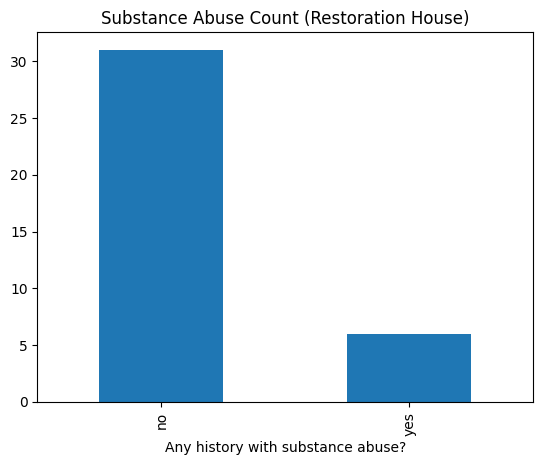

In [ ]:
import string
import re
rh["Any history with substance abuse?"] = rh["Any history with substance abuse?"].str.lower().str.strip().str.replace(f'[{re.escape(string.punctuation)}]', '', regex=True)
substance_issues = rh["Any history with substance abuse?"].map(lambda x: "yes" if isinstance(x, str) and x.strip().lower() != "no" else "no").value_counts()
substance_issues.plot(kind="bar")

plt.title("Substance Abuse Count (Restoration House)")

In [ ]:
rh["Date"] = rh["Completion time"].str.extract('^([^ ]*)')
rh.head(3)

,ID,Start time,Completion time,Email,Name,Client Name:,Date of Birth:,Questions?,Gender:,Phone Number:,...,"If Yes, please explain:",Any medical history or current health issues?,Any history with substance abuse?,"If yes, are you or have you been in rehab rehabilitation?",Are you currently in a Domestic relationship or a survivor of Domestic violence?,Any additional health information or special accommodations for staff to be aware of?,Have you previously applied for a registration at Thaddeus?,Any additional information that our Case managers should know?,Were you referred by another Agency/Organization or Thaddeus Employee?,Date
0,1,2023-08-31 12:19:13,2023-08-31 12:26:29,anonymous,NaN,NaN,5/19/1970,NaN,NaN,909-789-2399,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-08-31
1,2,2023-09-19 13:10:08,2023-09-19 13:11:46,anonymous,NaN,NaN,07/07/1991,NaN,Female,6264222926,...,NaN,Yes,no,No,Yes,Lupus,No,NaN,Maria,2023-09-19
2,3,2023-09-26 20:37:20,2023-09-26 20:39:31,anonymous,NaN,NaN,11/22/1973,NaN,Female,626-827-2149,...,NaN,No,NaN,No,Yes,NaN,No,NaN,Yes,2023-09-26


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


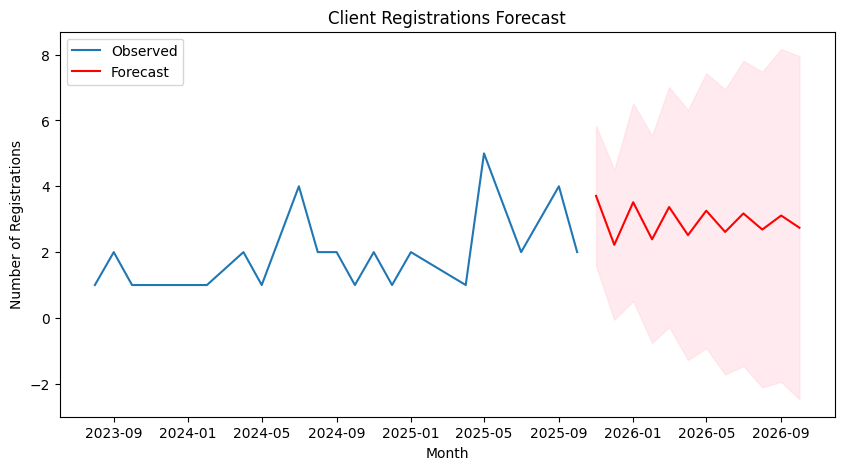

In [ ]:
rh["Date"] = pd.to_datetime(rh["Date"], errors="coerce")
rh = rh.dropna(subset=["Date"])
rh1 = rh.groupby(rh["Date"].dt.to_period("M")).size()
rh1.index = rh1.index.to_timestamp()
ts = rh1

model1 = ARIMA(ts, order=(1,1,1))
model_fit1 = model1.fit()

forecast1 = model_fit1.get_forecast(steps=12)
forecast_index1 = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq="MS")


plt.figure(figsize=(10,5))
plt.plot(ts, label="Observed")
plt.plot(forecast_index1, forecast1.predicted_mean, label="Forecast", color="red")
plt.fill_between(
    forecast_index1,
    forecast1.conf_int()["lower y"],
    forecast1.conf_int()["upper y"],
    color="pink", alpha=0.3
)
plt.title("Client Registrations Forecast")
plt.xlabel("Month")
plt.ylabel("Number of Registrations")
plt.legend()
plt.show()

After plotting this model, it would be safe to say we can anticipate about an average of 2-4 applicants every month signing up for the restoration house program. The plot is slightly erratic (in the sense it goes rapidly up and down) because the dataset is fairly small, meaning there is greater variance. The forecast is slightly more stable and fairly dependable enough to say about 2-4 people will sign up for this program.